# UNBSW-NB15 Intrusion Detection

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, pairwise_distances_argmin
from sklearn.metrics import pairwise_distances_argmin_min

from imblearn.over_sampling import BorderlineSMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import shap
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [ ]:
train = pd.read_csv("UNSW_NB15_training-set.csv", header=None)
test = pd.read_csv("UNSW_NB15_testing-set.csv", header=None)

columns = [
    "id","dur","proto","service","state","spkts","dpkts","sbytes","dbytes",
    "rate","sttl","dttl","sload","dload","sloss","dloss","sinpkt","dinpkt",
    "sjit","djit","swin","stcpb","dtcpb","dwin","tcprtt","synack","ackdat",
    "smean","dmean","trans_depth","response_body_len","ct_srv_src",
    "ct_state_ttl","ct_dst_ltm","ct_src_dport_ltm","ct_dst_sport_ltm",
    "ct_dst_src_ltm","is_ftp_login","ct_ftp_cmd","ct_flw_http_mthd",
    "ct_src_ltm","ct_srv_dst","is_sm_ips_ports","attack_cat","label"
]

train.columns = columns
test.columns = columns

train = train.iloc[1:].copy()
test = test.iloc[1:].copy()

## 2. Label Mapping & Filtering

In [ ]:
common_labels = set(train['attack_cat']) & set(test['attack_cat'])

train = train[train['attack_cat'].isin(common_labels)]
test = test[test['attack_cat'].isin(common_labels)]

X_train = train.drop(columns=["id", "attack_cat", "label"])
y_train = train["attack_cat"]

X_test = test.drop(columns=["id", "attack_cat", "label"])
y_test = test["attack_cat"]

print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({'Normal': 56000, 'Generic': 40000, 'Exploits': 33393, 'Fuzzers': 18184, 'DoS': 12264, 'Reconnaissance': 10491, 'Analysis': 2000, 'Backdoor': 1746, 'Shellcode': 1133, 'Worms': 130})
Test distribution: Counter({'Normal': 37000, 'Generic': 18871, 'Exploits': 11132, 'Fuzzers': 6062, 'DoS': 4089, 'Reconnaissance': 3496, 'Analysis': 677, 'Backdoor': 583, 'Shellcode': 378, 'Worms': 44})


## 3. Preprocessing
### FIX: LabelEncoder disimpan per kolom dalam dict agar tidak tertimpa

In [ ]:
categorical_cols = ["proto", "service", "state"]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col])

    # Handle unseen categories di test set
    X_test[col] = X_test[col].apply(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )

    X_test[col] = le.transform(X_test[col])

    label_encoders[col] = le

print("Categorical encoding done.")
print("Encoders saved:", list(label_encoders.keys()))

Categorical encoding done.
Encoders saved: ['proto', 'service', 'state']


## 4. Target Label Encoder & Scaling (Full Features)

In [ ]:
# Label encoder untuk target - fit hanya dari y_train
label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Scaling - fit hanya dari X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Classes:", label_encoder.classes_)
print("X_train_scaled shape:", X_train_scaled.shape)

Classes: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
X_train_scaled shape: (175341, 42)


## 5. Baseline: XGBoost tanpa Sampling (Unbalanced)

In [ ]:
print("Training baseline XGBoost (unbalanced)...")

model_xgb_unbalanced = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
model_xgb_unbalanced.fit(X_train_scaled, y_train_encoded)
y_pred_unbalanced = model_xgb_unbalanced.predict(X_test_scaled)

print("\n=== Baseline (Unbalanced) ===")
print(classification_report(y_test_encoded, y_pred_unbalanced,
                             target_names=label_encoder.classes_))

Training baseline XGBoost (unbalanced)...

=== Baseline (Unbalanced) ===
                precision    recall  f1-score   support

      Analysis       0.02      0.04      0.03       677
      Backdoor       0.04      0.15      0.07       583
           DoS       0.55      0.12      0.20      4089
      Exploits       0.62      0.83      0.71     11132
       Fuzzers       0.30      0.58      0.39      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.96      0.76      0.85     37000
Reconnaissance       0.93      0.81      0.87      3496
     Shellcode       0.38      0.79      0.51       378
         Worms       0.63      0.39      0.48        44

      accuracy                           0.76     82332
     macro avg       0.54      0.54      0.51     82332
  weighted avg       0.83      0.76      0.78     82332



## 6. Hybrid Sampling: KMeans Undersampling + BorderlineSMOTE

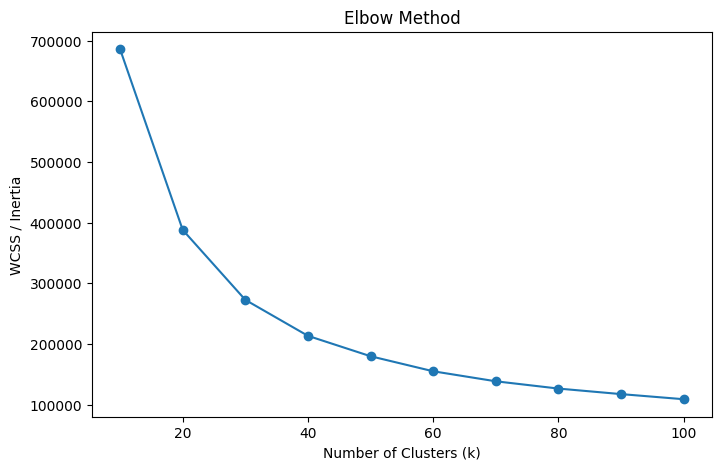

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_normal = X_train_scaled[y_train == 'Normal']

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_normal)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

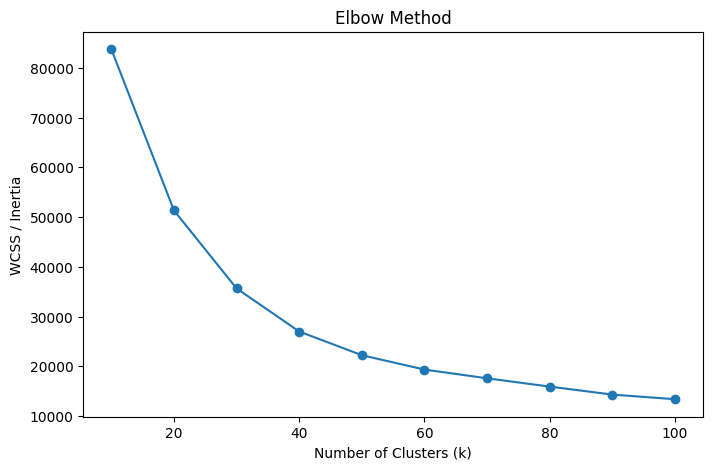

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_generic = X_train_scaled[y_train == 'Generic']

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_generic)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

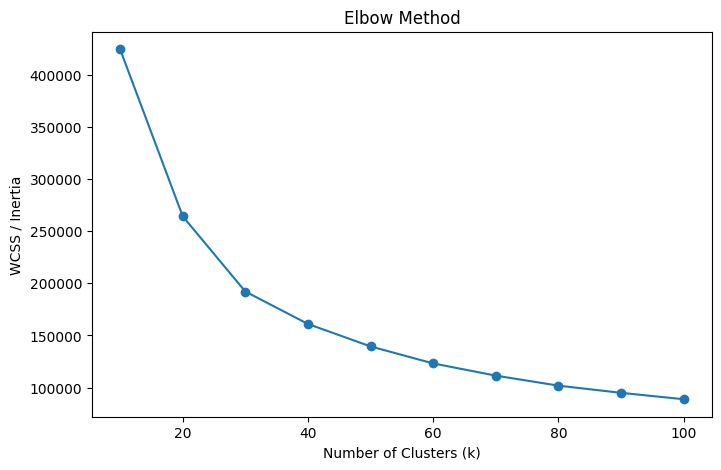

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_exploits = X_train_scaled[y_train == 'Exploits']

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_exploits)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
def kmeans_undersample(
    X,
    y,
    sampling_strategy,
    cluster_strategy,
    random_state=42
):

    X_result, y_result = [], []

    unique_classes = np.unique(y)

    rng = np.random.RandomState(random_state)

    for cls in unique_classes:

        # =====================================================
        # AMBIL DATA PER CLASS
        # =====================================================
        mask = (y == cls) if not hasattr(y, 'values') else (y.values == cls)

        X_cls = X[mask]

        # target jumlah setelah undersampling
        target_n = sampling_strategy.get(cls, len(X_cls))

        # jumlah cluster khusus tiap class
        n_cluster_cls = cluster_strategy.get(cls, 50)

        # =====================================================
        # MINORITY CLASS -> AMBIL SEMUA
        # =====================================================
        if len(X_cls) <= target_n:

            X_result.append(X_cls)
            y_result.extend([cls] * len(X_cls))

        # =====================================================
        # MAJORITY CLASS -> KMEANS CLUSTER SAMPLING
        # =====================================================
        else:

            print(f"\nClass : {cls}")
            print(f"Original samples : {len(X_cls)}")
            print(f"Target samples   : {target_n}")
            print(f"Clusters used    : {n_cluster_cls}")

            # KMeans clustering
            km = KMeans(
                n_clusters=n_cluster_cls,
                random_state=random_state,
                n_init=10,
                max_iter=300
            )

            cluster_labels = km.fit_predict(X_cls)

            # jumlah sampel yang diambil per cluster
            samples_per_cluster = target_n // n_cluster_cls

            selected_indices = []

            # =====================================================
            # SAMPLING TIAP CLUSTER
            # =====================================================
            for cluster_id in range(n_cluster_cls):

                cluster_idx = np.where(cluster_labels == cluster_id)[0]

                # jika isi cluster <= target per cluster
                if len(cluster_idx) <= samples_per_cluster:

                    selected_indices.extend(cluster_idx)

                else:

                    chosen = rng.choice(
                        cluster_idx,
                        size=samples_per_cluster,
                        replace=False
                    )

                    selected_indices.extend(chosen)

            selected_indices = np.array(selected_indices)

            # =====================================================
            # JIKA JUMLAH MASIH KURANG
            # =====================================================
            if len(selected_indices) < target_n:

                remaining = np.setdiff1d(
                    np.arange(len(X_cls)),
                    selected_indices
                )

                extra = rng.choice(
                    remaining,
                    size=target_n - len(selected_indices),
                    replace=False
                )

                selected_indices = np.concatenate([
                    selected_indices,
                    extra
                ])

            X_result.append(X_cls[selected_indices])

            y_result.extend([cls] * len(selected_indices))

    # =====================================================
    # GABUNGKAN SEMUA CLASS
    # =====================================================
    X_out = np.vstack(X_result)
    y_out = np.array(y_result)

    return X_out, y_out

In [ ]:
from collections import Counter
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# =========================================================
# SAMPLING STRATEGY
# =========================================================

sampling_strategy_under = {
    'Normal': 20000,
    'Generic': 20000,
    'Exploits': 20000
}

cluster_strategy = {
    'Normal': 40,
    'Generic': 40,
    'Exploits': 40
}

sampling_strategy_smote = {
    'DoS': 15000,
    'Reconnaissance': 15000,
    'Analysis': 10000,
    'Backdoor': 10000,
    'Shellcode': 10000,
    'Worms': 5000
}

# =========================================================
# DEFINISI EKSPERIMEN
# =========================================================

experiments = {

    "Hybrid Sampling": "hybrid",

    "KMeans Only": "kmeans",

    "BorderlineSMOTE Only": "smote"

}

# =========================================================
# LOOP EKSPERIMEN
# =========================================================

for exp_name, exp_type in experiments.items():

    print("="*70)
    print(exp_name)
    print("="*70)

    # -----------------------------------------------------
    # 1. Tentukan data hasil sampling
    # -----------------------------------------------------

    if exp_type == "hybrid":

        # KMeans
        X_sample, y_sample = kmeans_undersample(
            X_train_scaled,
            y_train,
            sampling_strategy=sampling_strategy_under,
            cluster_strategy=cluster_strategy,
            random_state=42
        )

        # BorderlineSMOTE
        smote = BorderlineSMOTE(
            kind='borderline-2',
            sampling_strategy=sampling_strategy_smote,
            k_neighbors=3,
            random_state=42
        )

        X_sample, y_sample = smote.fit_resample(X_sample, y_sample)

    elif exp_type == "kmeans":

        X_sample, y_sample = kmeans_undersample(
            X_train_scaled,
            y_train,
            sampling_strategy=sampling_strategy_under,
            cluster_strategy=cluster_strategy,
            random_state=42
        )

    elif exp_type == "smote":

        smote = BorderlineSMOTE(
            kind='borderline-2',
            sampling_strategy=sampling_strategy_smote,
            k_neighbors=3,
            random_state=42
        )

        X_sample, y_sample = smote.fit_resample(
            X_train_scaled,
            y_train
        )

    print("\nClass Distribution:")
    print(Counter(y_sample))

    # -----------------------------------------------------
    # 2. Encode label
    # -----------------------------------------------------

    y_sample_encoded = label_encoder.transform(y_sample)

    # -----------------------------------------------------
    # 3. Train XGBoost
    # -----------------------------------------------------

    model = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_sample, y_sample_encoded)

    # -----------------------------------------------------
    # 4. Predict
    # -----------------------------------------------------

    y_pred = model.predict(X_test_scaled)

    print(classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    ))

Hybrid Sampling

Class : Exploits
Original samples : 33393
Target samples   : 20000
Clusters used    : 40

Class : Generic
Original samples : 40000
Target samples   : 20000
Clusters used    : 40

Class : Normal
Original samples : 56000
Target samples   : 20000
Clusters used    : 40

Class Distribution:
Counter({np.str_('Exploits'): 20000, np.str_('Generic'): 20000, np.str_('Normal'): 20000, np.str_('Fuzzers'): 18184, np.str_('DoS'): 15000, np.str_('Reconnaissance'): 15000, np.str_('Analysis'): 10000, np.str_('Backdoor'): 10000, np.str_('Shellcode'): 10000, np.str_('Worms'): 5000})
                precision    recall  f1-score   support

      Analysis       0.06      0.31      0.11       677
      Backdoor       0.05      0.38      0.09       583
           DoS       0.41      0.30      0.35      4089
      Exploits       0.77      0.63      0.69     11132
       Fuzzers       0.25      0.65      0.36      6062
       Generic       1.00      0.97      0.98     18871
        Normal     